## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 5 (Section 001 - Spring 2021)

The quiz is set up so that even if you get stuck on one question there are opportunities to get points on the other questions, so consider jumping ahead if you feel like you aren't making progress and then come back later if you have time.  Also, you will receive partial credit for pseudocode, even if your python code does not function correctly.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity will result in you receiving a zero in this course.

**Total points possible: 20**

---
## Academic integrity statement (1 point)

In the markdown cell below, put your personal academic integrity statement (composed during Day04 In-Class Assignment). By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Compartmental Models

###ANSWER### (for making sure this gets removed)

**Note to instructors:** In this section, the goal provide students with the opportunity to convert diagrams of relationships between compartments and differential equations.  And, interpret provided code.

The following diagram is a visual display of a model of PFAS chemicals moving between different water supplies (lakes) in Michigan.  Let's say that we have three lakes, $A$, $B$, and $C$ connected via streams in the following way, with a factory dumping PFAS pollutants at a rate of, $p$, into lake $A$:

<div align="center"><img src="https://i.ibb.co/dW7VGLk/pond-model-001.png" width=300px></div>

&#9989;&nbsp; **Question 1 [1 points]**: The system of differential equations to describe this model would be best represented as the equations in column EQ1, EQ2, or EQ3?

| &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; EQ1: &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; |  &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp;EQ2: &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; |  &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp;EQ3:&emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; &emsp;&emsp; |  
| :-: |  :-: |  :-: | 
| $$ \frac{dA}{dt} = qA + sC $$ | $$ \frac{dA}{dt} = p - qA + sC $$ | $$ \frac{dA}{dt} = p - qA + sC $$ | 
| $$ \frac{dB}{dt} = qA + rB $$ | $$ \frac{dB}{dt} = qA - rB $$ | $$ \frac{dB}{dt} = - qA + rB $$ |
| $$ \frac{dC}{dt} = rB - sC $$ | $$ \frac{dC}{dt} = rB - sC $$ | $$ \frac{dC}{dt} = - rB - sC $$ |





<font size=+3>&#9998;</font> Is it "EQ1", "EQ2", or "EQ3" here: 


In [78]:
### ANSWER ###
# EQ2

&#9989;&nbsp; **Question 2 [4 points]**: The following code implements this compartmental model and uses `solve_ivp()` to find the amount of pollutants in the lakes A, B, C.  Make a single plot that displays the evolution of all three variables, A, B, and C as a function time. Each line should be a different color and your plot should contain a 𝑥-axis label, a 𝑦-axis label, and a legend.


In [79]:
# Solve compartmental model of PFAS pollutants in 3 Lakes

# Import needed modules
from scipy.integrate import solve_ivp
import math
import numpy as np

# Define the derivatives function
def derivs(t, vals, p, q, r, s):
    A, B, C = vals
    dAdt = p - q*A + s*C 
    dBdt = q*A - r*B
    dCdt = r*B - s*C
    return dAdt, dBdt, dCdt

# Solve the system

# Initial conditions
A0 = 10
B0 = 10
C0 = 10
ICs = [A0, B0, C0] # initial amounts in pounds

# time array
t_start = 0
t_end = 2880
t = np.arange(t_start, t_end, 1.0)  # Time in minutes

# Model parameters
p = 0.125
q, r, s = 0.01, 0.001, 0.001

# Call solve_ivp()
sol = solve_ivp(derivs, (t_start,t_end), ICs, t_eval=t, args=(p,q,r,s))

# Unpack the solution
A = sol.y[0,:]
B = sol.y[1,:]
C = sol.y[2,:]

In [73]:
# Put your pseudocode and code here for plotting


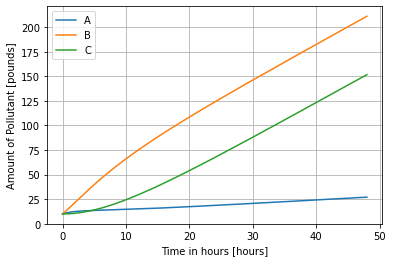

In [74]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(1)
plt.plot(t/60,A,label="A")
plt.plot(t/60,B,label="B")
plt.plot(t/60,C,label="C")
plt.xlabel("Time in hours [hours]")
plt.ylabel("Amount of Pollutant [pounds]")
plt.legend()
plt.grid()

&#9989;&nbsp; **Question 3 [1 points]**: Based on the implementation above, what is the rate (the number from the code above) for which PFAS moves from Lake A to Lake B?



<font size=+3>&#9998;</font> *Put your answer here*


In [75]:
### ANSWER ###
# 0.01
# 0.01*A is also acceptable
# Partial credit for q*A

&#9989;&nbsp; **Question 4 [6 points]**: You developed a novel technology to remove PFAS from water supplies.  You set up your first operation on Lake B and it removes PFAS from Lake B at a constant fixed rate of `removal=0.05.`  Copy and modify the above code to represent this new system.  

Make a single plot that displays the evolution of all three variables, A, B, and C with the addition of your PFAS removal as a function time. Each line should be a different color and your plot should contain a 𝑥-axis label, a 𝑦-axis label, and a legend.



In [80]:
# Put your pseudocode and  code here


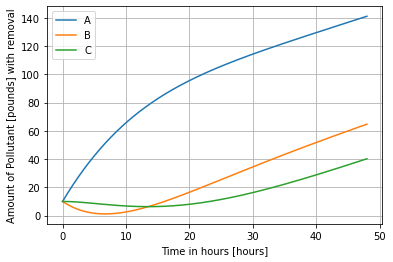

In [81]:
### ANSWER ###
# Solve compartmental model of PFAS pollutants in 3 Lakes with removal

# Import needed modules
from scipy.integrate import solve_ivp
import math
import numpy as np

# Define the derivatives function
def derivs(t, vals, p, q, r, s):
    A, B, C = vals
    dAdt = p - q*A + s*C 
    dBdt = q*A - r*B - 0.05
    dCdt = r*B - s*C
    return dAdt, dBdt, dCdt

# Solve the system

# Initial conditions
A0 = 10
B0 = 10
C0 = 10
ICs = [A0, B0, C0]

# time array
t_start = 0
t_end = 2880
t = np.arange(t_start, t_end, 1.0)  # Time in minutes

# Model parameters
p = 0.125
q, r, s = 0.001, 0.001, 0.001

# Call solve_ivp()
sol = solve_ivp(derivs, (t_start,t_end), ICs, t_eval=t, args=(p,q,r,s))

# Unpack the solution
A = sol.y[0,:]
B = sol.y[1,:]
C = sol.y[2,:]

# Plot for 2 points
# Import needed modules
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(1)
plt.plot(t/60,A,label="A")
plt.plot(t/60,B,label="B")
plt.plot(t/60,C,label="C")
plt.xlabel("Time in hours [hours]")
plt.ylabel("Amount of Pollutant [pounds] with removal")
plt.legend()
plt.grid()

---
## Part 2: Agent Based Models

<img src = "https://www.aquariumarchitecture.com/site/wp-content/uploads/2013/06/aquarium-architecture-gala-26-1600x1000.jpg" width = 400>
You work at an aquarium and one of the challenges is that children like to touch the glass walls when they are watching the marine wildlife. Especially now, this poses an infection risk for everyone touching the walls (germs!).  You would like to use an agent based model to estimate how often to disinfect the visitor side of the aquarium walls.

We will assume this is a one dimensional hallway with an exhibit (glass) on only one side and it is 100 steps long.  Also, this is a oneway hallway with visitors always starting from one end and moving to the other end.  Visitors move along the hallway with the same, fixed step size.  Here are the rules of your model:
1. A child tends to touch the wall somewhere in the first half of the hallway.
2. Once a child touches the wall, they see how fun it is and touch it again every 2-20 steps until the end of the hallway.

Based on guidelines, you decide to disinfect the wall when any one location along the wall has received over 50 touches.




Text(0.5, 1.0, 'Number of touches at each location after 1000 children')

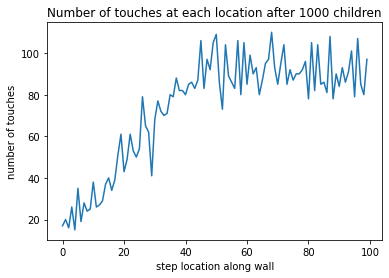

In [89]:
# Agent Based Model of touches on a aquarium wall

import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

num_steps_along_wall =100

wall = np.zeros(num_steps_along_wall)  # 100 step long wall, to record number of touches

number_children = 1000
for child in range(number_children):
    next_touch = random.randint(0,np.round(num_steps_along_wall/2)) # location where first touch occurs in first half of hall way
    while next_touch<num_steps_along_wall:
        wall[next_touch]+=1
        next_touch = next_touch+random.randint(2,20)  # location of next touch is 2 to 20 steps from current location
            
plt.plot(wall)
plt.xlabel('step location along wall')
plt.ylabel('number of touches')
plt.title('Number of touches at each location after '+str(child+1)+ ' children')


&#9989;&nbsp; **Question 5 [2 points]**: In your own words, what is the purpose of the inner while loop:

```while next_touch < num_steps_along_wall:```



<font size=+3>&#9998;</font> *Put your answer here*


&#9989;&nbsp; **Question 7 [1 points]**: Based on the rules above and the simulation above for 1000 children visiting, is it time to clean the walls of the aquarium? Briefly explain.



<font size=+3>&#9998;</font> *Put your answer here*


&#9989;&nbsp; **Question 8 [4 points]**: Using the code above, how often should you be cleaning the wall.  In other words, after approximately how many children should you clean the wall?  ( you can modify the code to automatically get an answer or try multiple manual modifications of the code to approximate this answer).



In [88]:
# Put your answer here (does not necessarily need more code, up to you)


Reached 50 touches with 380 children TIME TO CLEAN!


Text(0.5, 1.0, 'Number of touches at each location after 381 children')

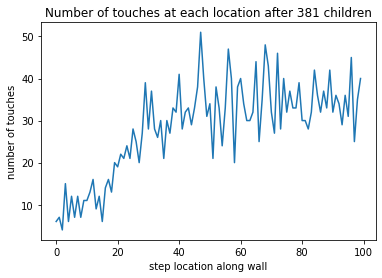

In [87]:
### ANSWER ###

# Agent Based Model of touches on a aquarium wall

import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

num_steps_along_wall =100

wall = np.zeros(num_steps_along_wall)  # 100 step long wall, to record number of touches

number_children = 1000
for child in range(number_children):
    next_touch = random.randint(0,np.round(num_steps_along_wall/2)) # first step occurs in first half of hall way
    while next_touch<num_steps_along_wall:
        wall[next_touch]+=1
        next_touch = next_touch+random.randint(2,20)  # next touch is 2 to 20 steps from current location
    
    max_touch = np.max(wall)
    if(max_touch>50):
        print('Reached 50 touches with '+str(child)+' children TIME TO CLEAN!')
        break
    
    
plt.plot(wall)
plt.xlabel('step location along wall')
plt.ylabel('number of touches')
plt.title('Number of touches at each location after '+str(child+1)+ ' children')


# ANSWER AROUND 350-500 is suitable


---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #5, and upload it there.

&#169; Copyright 2021,  Michigan State University Board of Trustees